# Image Classification Using Handcrafted Features
### A Step-by-Step Feature Engineering and ML Approach
This notebook explore how to classify images by manually extracting features such as edges, color histograms, and texture, followed by training classical ML models (SVM, KNN, Logistic Regression).


## 1. Import Required Libraries
 This section loads all necessary Python libraries for:
 - Image processing (skimage)
 - Numerical operations (numpy)
 - Machine learning models (scikit-learn)
 - Plotting and visualizations (matplotlib)


In [1]:
from pathlib import Path
import numpy as np, json, joblib, time, warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False
from skimage.io import imread
from skimage.transform import resize
from skimage.color import rgb2gray
from skimage.feature import hog, local_binary_pattern
import matplotlib.pyplot as plt
import pandas as pd

## 2. Load and Inspect the Dataset
This section loads the image dataset from disk.

We visualize sample images to understand variation.

This helps verify that the dataset is loaded correctly before extraction.


In [3]:

DATA_DIR = Path(r"/Users/jathusan/Documents/trashnet.ia/data_2")
IMG_SIZE = (224, 224)
HOG_PIXELS_PER_CELL = (16,16)
HOG_CELLS_PER_BLOCK = (2,2)
HOG_ORIENTATIONS = 9
LBP_P, LBP_R = 8, 1  
LBP_BINS = LBP_P + 2 
SEED = 42
N_FOLDS = 5

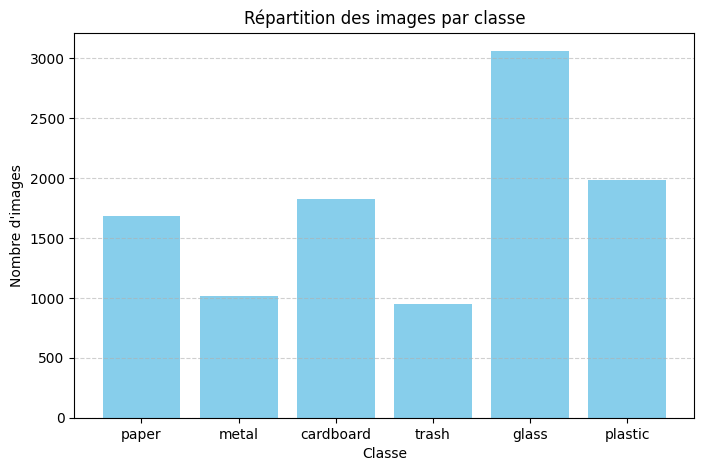

 Nombre total d'images : 10517

  paper      : 1680 images ( 16.0 %)
  metal      : 1020 images (  9.7 %)
  cardboard  : 1825 images ( 17.4 %)
  trash      :  947 images (  9.0 %)
  glass      : 3061 images ( 29.1 %)
  plastic    : 1984 images ( 18.9 %)

Classe la plus grande : 'glass' (3061)
Classe la plus petite : 'trash' (947)
Ratio max/min = 3.23
Déséquilibre modéré — recommander class_weight='balanced'


In [5]:

counts = {d.name: len(list(d.glob("*.*"))) for d in DATA_DIR.iterdir() if d.is_dir()}
total = sum(counts.values())
plt.figure(figsize=(8,5))
plt.bar(counts.keys(), counts.values(), color="skyblue")
plt.title("Répartition des images par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
print(f" Nombre total d'images : {total}\n")
for k, v in counts.items():
    print(f"  {k:<10} : {v:>4} images ({v/total*100:5.1f} %)")
max_class = max(counts, key=counts.get)
min_class = min(counts, key=counts.get)
ratio = counts[max_class] / max(1, counts[min_class])
print(f"\nClasse la plus grande : '{max_class}' ({counts[max_class]})")
print(f"Classe la plus petite : '{min_class}' ({counts[min_class]})")
print(f"Ratio max/min = {ratio:.2f}")
if ratio < 2:
    print("Données équilibrées (faible déséquilibre)")
elif ratio < 10:
    print("Déséquilibre modéré — recommander class_weight='balanced'")
else:
    print("Déséquilibre fort — recommander oversampling ou data augmentation")


## 3. Preprocessing Steps & Handcrafted Feature Extraction

Here we apply basic preprocessing:
- **Resize all images** to the same dimensions
- Convert images to **grayscale** (if required)
- **Normalize pixel** intensitie to the range [0, 1]

These steps prepare the images for consistent feature extraction.

We manually create features from each image. These may include:

- Edge detection (Sobel, Canny)
- Texture (**LBP**)
- Shape descriptors (**HOB**)
- Color histograms

For each image, we combine all extracted features into a single 1-D feature vector. These vectors are stacked together into **X (shape: num_samples × num_features)**. The matching class labels are stored in **y**.

This matrice will be used for machine learning training.


In [8]:
def extract_features(img, use_hog=True, use_lbp=True):
    img = resize(img, IMG_SIZE, anti_aliasing=True)
    gray = rgb2gray(img)
    feats = []
    if use_hog:
        h = hog(
            gray,
            orientations=HOG_ORIENTATIONS,
            pixels_per_cell=HOG_PIXELS_PER_CELL,
            cells_per_block=HOG_CELLS_PER_BLOCK,
            feature_vector=True
        )
        feats.append(h.astype(np.float32))
    if use_lbp:
        lbp = local_binary_pattern(gray, P=LBP_P, R=LBP_R, method='uniform')
        hist, _ = np.histogram(lbp, bins=np.arange(0, LBP_BINS+1), range=(0, LBP_BINS), density=True)
        feats.append(hist.astype(np.float32))
    return np.concatenate(feats)
classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
X, y, paths = [], [], []
t0 = time.time()
for ci, cname in enumerate(classes):
    for p in (DATA_DIR / cname).glob("*.*"):
        try:
            img = imread(p)
            feats = extract_features(img, use_hog=True, use_lbp=True)
            X.append(feats); y.append(ci); paths.append(str(p))
        except Exception:
            pass
X, y = np.array(X), np.array(y)
print(f"Features: X={X.shape}, n_classes={len(classes)}, time={time.time()-t0:.1f}s")
with open("labels.json","w", encoding="utf-8") as f:
    json.dump(classes, f, ensure_ascii=False, indent=2)


Features: X=(10188, 6094), n_classes=6, time=358.3s


# Create column names for the feature vector
feat_cols = [f"f{i}" for i in range(X.shape[1])]

# Build a DataFrame with features + labels
df_features = pd.DataFrame(X, columns=feat_cols)
df_features["label_idx"] = y
df_features["label_name"] = [classes[i] for i in y]

# Show a few rows
df_features.head()

## 4. Train–Test Split
We split the feature matrix into:
- **Training set** (used to fit the ML models)
- **Test set** (used to evaluate generalization)

We use stratified splitting to preserve class balance.


In [10]:
X_tr, X_te, y_tr, y_te, paths_tr, paths_te = train_test_split(
    X, y, paths, test_size=0.2, random_state=SEED, stratify=y
)
print("Train:", X_tr.shape, "Test:", X_te.shape)


Train: (8150, 6094) Test: (2038, 6094)


## 5. Train Classical Machine Learning Models
We train models such as:

- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- RandomForest
- HistGradientBoosting

Each model learns patterns in the training features to classify new images.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False
models = {
    "SVM-RBF": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", SVC(C=10, gamma="scale", random_state=SEED))
    ]),
    "RandomForest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=600, max_features="sqrt", random_state=SEED, n_jobs=-1
        ))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),
    "HistGB": Pipeline([
        ("clf", HistGradientBoostingClassifier(
            learning_rate=0.1,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=SEED
        ))
    ])
}
if HAS_XGB:
    models["XGBoost"] = Pipeline([
        ("clf", XGBClassifier(
            n_estimators=600, learning_rate=0.05, max_depth=6,
            subsample=0.9, colsample_bytree=0.9,
            random_state=SEED, n_jobs=-1, tree_method="hist"
        ))
    ])
list(models.keys())


['SVM-RBF', 'RandomForest', 'KNN', 'HistGB']

## 6. Model Evaluation
We evaluate the trained models on the test set.

The metrics include:
- **Accuracy**: overall correctnes
- **Precision**, **Recall**, **F1-Score**: per-class performance

The classification report highlights which classes perform strongly or poorly.



In [14]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import time, pandas as pd
rows = []
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
for name, pipe in models.items():
    t0 = time.time()
    scores = cross_validate(
        pipe, X_tr, y_tr, cv=cv,
        scoring={'acc':'accuracy', 'f1m':'f1_macro'},
        n_jobs=1,            # <— clé anti-freeze dans notebook Windows
        return_train_score=False
    )
    rows.append({
        "Model": name,
        "Acc_mean": scores['test_acc'].mean(), "Acc_std": scores['test_acc'].std(),
        "F1m_mean": scores['test_f1m'].mean(), "F1m_std": scores['test_f1m'].std(),
        "TrainCV_time_s": time.time()-t0
    })
    print(f"{name:16s} | Acc {scores['test_acc'].mean():.3f}±{scores['test_acc'].std():.3f} | "
          f"F1m {scores['test_f1m'].mean():.3f}±{scores['test_f1m'].std():.3f}")
results = pd.DataFrame(rows).sort_values("F1m_mean", ascending=False).reset_index(drop=True)
results

SVM-RBF          | Acc 0.653±0.005 | F1m 0.619±0.008
RandomForest     | Acc 0.566±0.009 | F1m 0.489±0.010
KNN              | Acc 0.452±0.011 | F1m 0.416±0.009
HistGB           | Acc 0.625±0.009 | F1m 0.574±0.010


,Model,Acc_mean,Acc_std,F1m_mean,F1m_std,TrainCV_time_s
0,SVM-RBF,0.653129,0.005259,0.619260,0.008014,319.279419
1,HistGB,0.625152,0.009050,0.574305,0.010219,336.179728
2,RandomForest,0.566257,0.008716,0.489218,0.010139,110.659609
3,KNN,0.451777,0.010886,0.416406,0.008993,4.846404


Best Model: SVM-RBF

- Accuracy: 0.653 ± 0.005
- F1-score: 0.619 ± 0.008
- Train time (CV): ~319.27 s

Interpretation:
- SVM-RBF delivers the highest and most stable performance among all tested models.
- Its accuracy and F1-score indicate strong classification ability with consistent results.
- Although training is relatively slow, the significant performance gain makes it the most effective model for this feature set.


Best by CV (F1-macro): SVM-RBF

Test set performance
Accuracy: 0.6869479882237488
F1-macro: 0.6496435914355451

Classification report:

              precision    recall  f1-score   support

   cardboard      0.713     0.683     0.697       356
       glass      0.672     0.817     0.737       579
       metal      0.529     0.365     0.432       197
       paper      0.713     0.779     0.745       335
     plastic      0.713     0.662     0.686       390
       trash      0.721     0.514     0.600       181

    accuracy                          0.687      2038
   macro avg      0.677     0.637     0.650      2038
weighted avg      0.684     0.687     0.680      2038



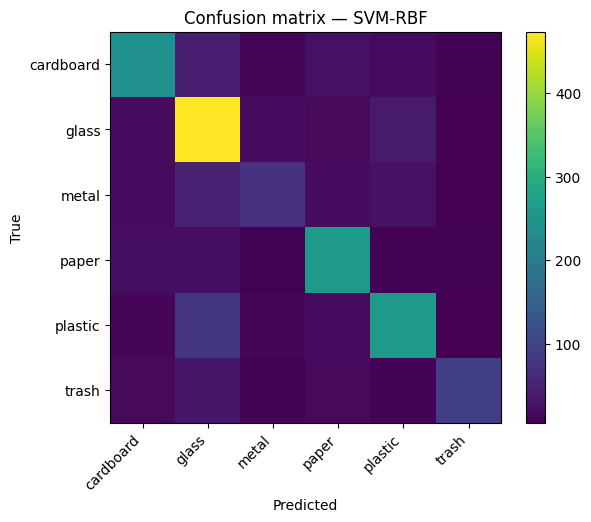

['models/handcrafted/SVM-RBF.joblib']

In [22]:
best_name = results.iloc[0]["Model"]
best_pipe = models[best_name]
print("Best by CV (F1-macro):", best_name)
best_pipe.fit(X_tr, y_tr)
y_pred = best_pipe.predict(X_te)
print("\nTest set performance")
print("Accuracy:", accuracy_score(y_te, y_pred))
print("F1-macro:", f1_score(y_te, y_pred, average="macro"))
print("\nClassification report:\n")
print(classification_report(y_te, y_pred, target_names=classes, digits=3))
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title(f"Confusion matrix — {best_name}")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45, ha="right")
plt.yticks(tick_marks, classes)
plt.tight_layout()
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()
Path("models/handcrafted").mkdir(parents=True, exist_ok=True)
joblib.dump(best_pipe, Path("models/handcrafted") / f"{best_name.replace(' ','_')}.joblib")


The SVM-RBF model achieves strong test performance:
- Accuracy: 0.686
- F1-macro: 0.649

We see that paper and plastic are classified with the most accurately.

Trash is also well recognized.

Metal is the hardest class, with lower recall and more confusion.

The confusion matrix shows clear diagonals for paper, plastic, and trash, confirming stable predictions. Most mistakes happen when metal looks similar to other classes.


## 7. Visualization of Predictions
This code loads a few sample images and extracts two types of handcrafted features:
- **HOG** (edges and gradients)
- **LBP** (texture patterns)

Before extracting features, the images are:
1) Resized to 224×224
2) Converted to grayscale
3) Preprocessed with contrast enhancement and light blurring

The code then compares:
- HOG before vs after preprocessing
- LBP before vs after preprocessing
- LBP histograms before vs after

Finally, it displays all results in plots to show how preprocessing improves edge clarity and texture extraction for classification.



Images test : [PosixPath('/Users/jathusan/Documents/trashnet.ia/data_2/glass/glass_4317.jpg'), PosixPath('/Users/jathusan/Documents/trashnet.ia/data_2/paper/paper_926.jpg'), PosixPath('/Users/jathusan/Documents/trashnet.ia/data_2/plastic/plastic_747.jpg')]


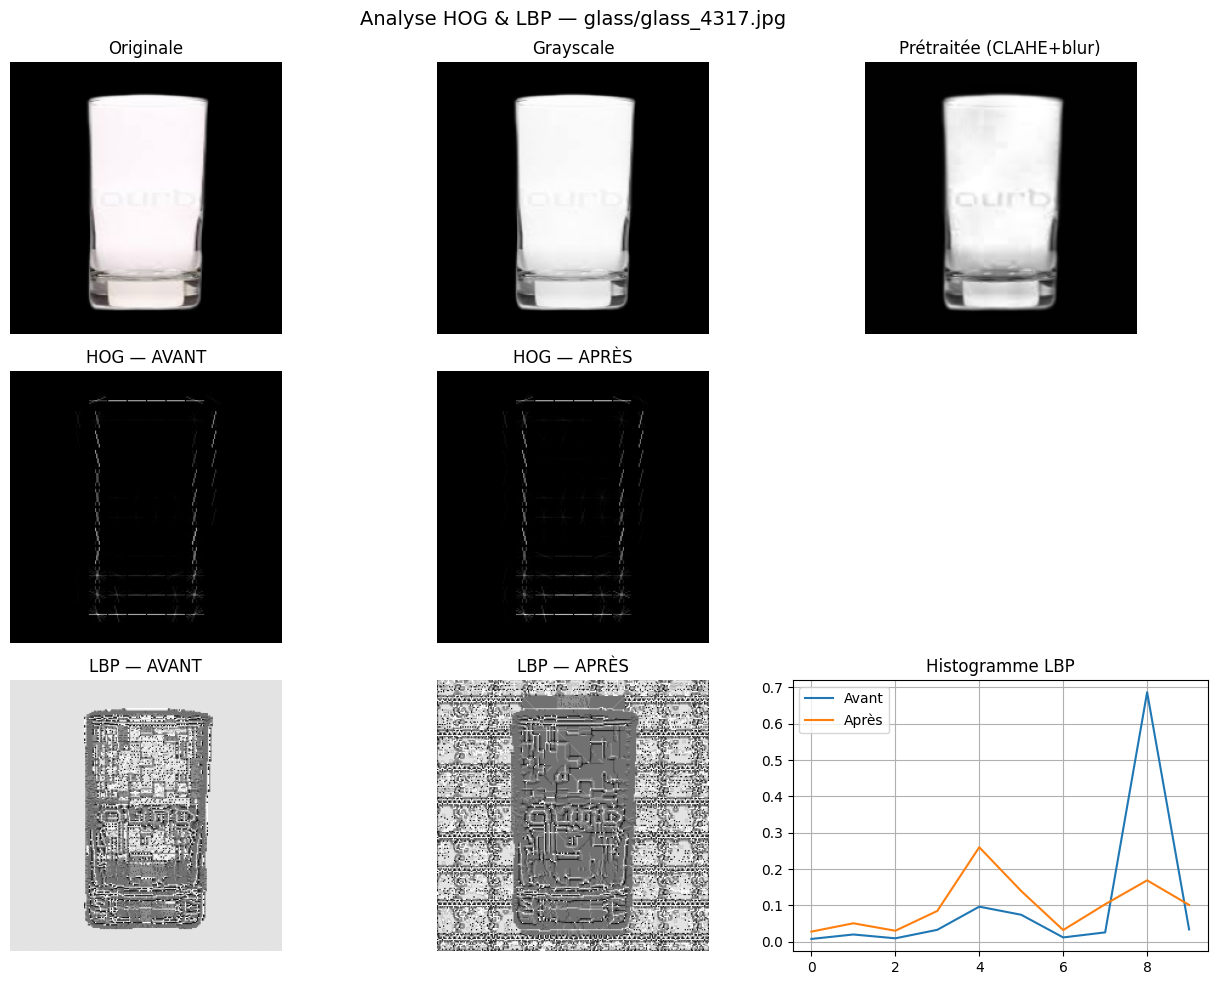

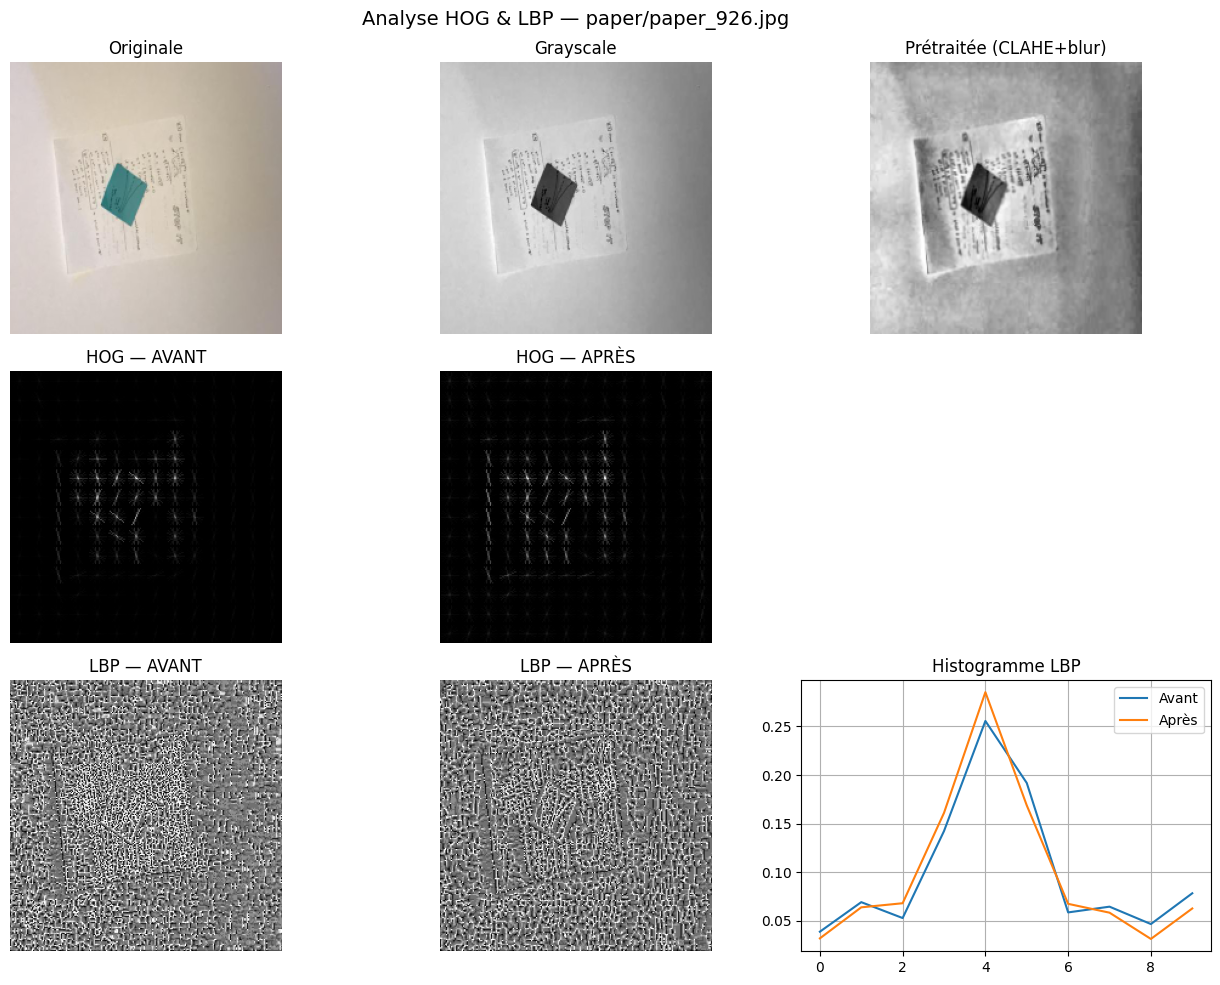

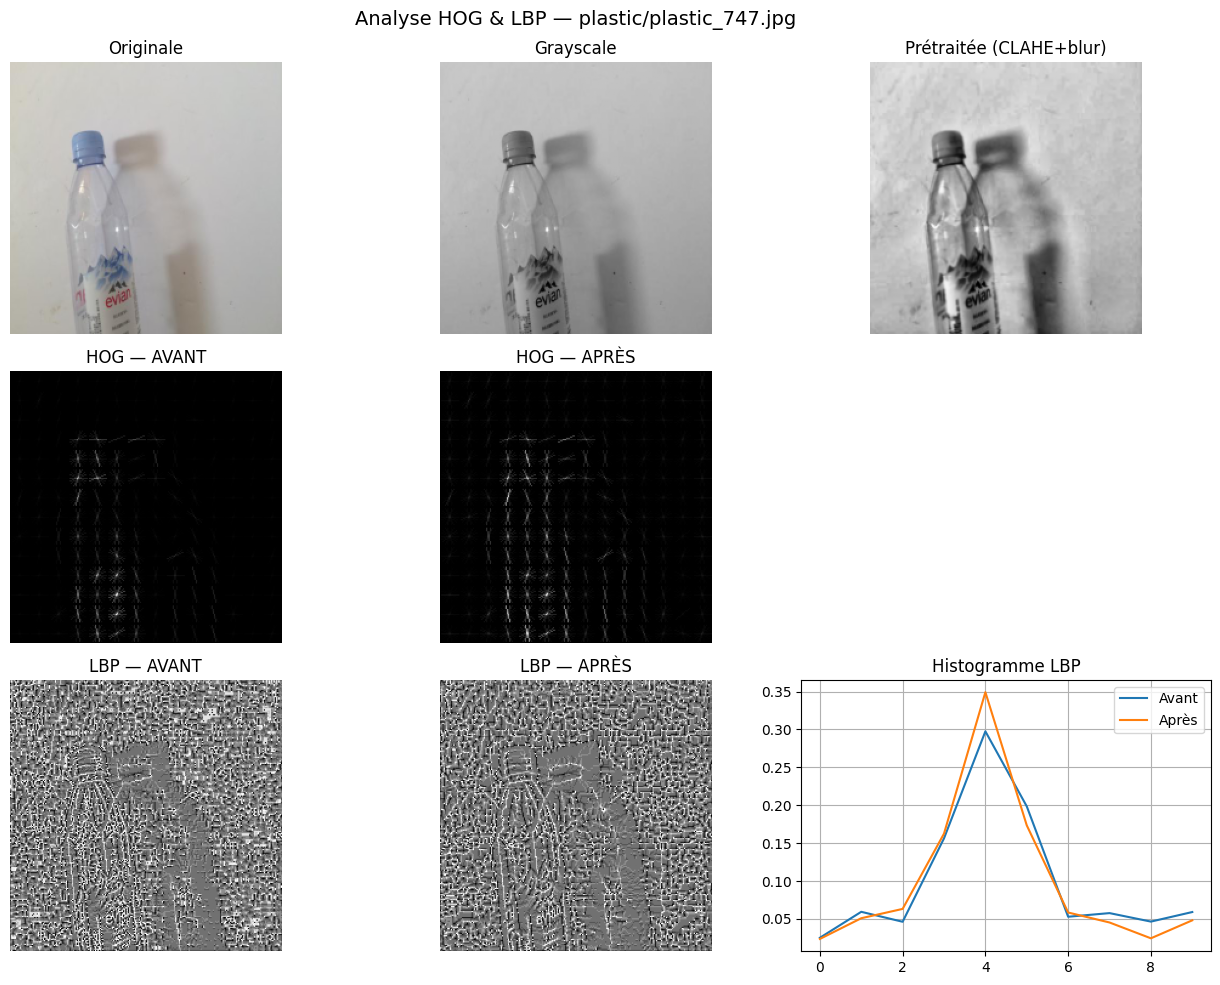

In [27]:
from skimage.io import imread
from skimage.transform import resize
from skimage.color import rgb2gray
from skimage.feature import hog, local_binary_pattern
from skimage import exposure
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
DATA_DIR = Path(r"/Users/jathusan/Documents/trashnet.ia/data_2")
#ne pas toucher c'est les paramètres
IMG_SIZE = (224, 224)
LBP_P, LBP_R = 8, 1
LBP_BINS = LBP_P + 2
def preprocess_gray(img_gray):
    """Prétraitement"""
    clahe = exposure.equalize_adapthist(img_gray, clip_limit=0.02)
    blurred = resize(clahe, (int(IMG_SIZE[0]*0.98), int(IMG_SIZE[1]*0.98)), anti_aliasing=True)
    blurred = resize(blurred, IMG_SIZE, anti_aliasing=True)
    return blurred

def compute_hog(gray, visualize=True):
    return hog(
        gray,
        orientations=9,
        pixels_per_cell=(16,16),
        cells_per_block=(2,2),
        visualize=visualize
    )
def compute_lbp(gray):
    lbp = local_binary_pattern(gray, P=LBP_P, R=LBP_R, method='uniform')
    hist, _ = np.histogram(lbp, bins=np.arange(0, LBP_BINS+1), range=(0, LBP_BINS), density=True)
    return lbp, hist
#tst
sample_paths = []
for cname in ["glass", "paper", "plastic"]:
    p = next((DATA_DIR/cname).glob("*.*"))
    sample_paths.append(p)
print("Images test :", sample_paths)
for p in sample_paths:
    img = imread(p)
    img_resized = resize(img[..., :3], IMG_SIZE, anti_aliasing=True)
    gray = rgb2gray(img_resized)
    gray_pp = preprocess_gray(gray)
    _, hog_vis_before = compute_hog(gray, visualize=True)
    _, hog_vis_after = compute_hog(gray_pp, visualize=True)
    lbp_before, hist_before = compute_lbp(gray)
    lbp_after, hist_after = compute_lbp(gray_pp)
    fig = plt.figure(figsize=(13,10))
    fig.suptitle(f"Analyse HOG & LBP — {p.parent.name}/{p.name}", fontsize=14)
    ax1 = plt.subplot(3,3,1); ax1.imshow(img_resized); ax1.set_title("Originale"); ax1.axis('off')
    ax2 = plt.subplot(3,3,2); ax2.imshow(gray, cmap='gray'); ax2.set_title("Grayscale"); ax2.axis('off')
    ax3 = plt.subplot(3,3,3); ax3.imshow(gray_pp, cmap='gray'); ax3.set_title("Prétraitée (CLAHE+blur)"); ax3.axis('off')
    ax4 = plt.subplot(3,3,4); ax4.imshow(hog_vis_before, cmap='gray'); ax4.set_title("HOG — AVANT"); ax4.axis('off')
    ax5 = plt.subplot(3,3,5); ax5.imshow(hog_vis_after, cmap='gray'); ax5.set_title("HOG — APRÈS"); ax5.axis('off')
    ax6 = plt.subplot(3,3,7); ax6.imshow(lbp_before, cmap='gray'); ax6.set_title("LBP — AVANT"); ax6.axis('off')
    ax7 = plt.subplot(3,3,8); ax7.imshow(lbp_after, cmap='gray'); ax7.set_title("LBP — APRÈS"); ax7.axis('off')
    ax8 = plt.subplot(3,3,9)
    ax8.plot(hist_before, label="Avant")
    ax8.plot(hist_after, label="Après")
    ax8.set_title("Histogramme LBP")
    ax8.legend(); ax8.grid()
    plt.tight_layout()
    plt.show()
